# Momentum
:label:`sec_momentum`

In :numref:`sec_sgd` we reviewed what happens when performing stochastic gradient descent, i.e., when performing optimization where only a noisy variant of the gradient is available. In particular, we noticed that for noisy gradients we need to be extra cautious when it comes to choosing the learning rate in the face of noise. If we decrease it too rapidly, convergence stalls. If we are too lenient, we fail to converge to a good enough solution since noise keeps on driving us away from optimality.

## Basics

In this section, we will explore more effective optimization algorithms, especially for certain types of optimization problems that are common in practice.


### Leaky Averages

The previous section saw us discussing minibatch SGD as a means for accelerating computation. It also had the nice side-effect that averaging gradients reduced the amount of variance. The minibatch stochastic gradient descent can be calculated by:

$$\mathbf{g}_{t, t-1} = \partial_{\mathbf{w}} \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} f(\mathbf{x}_{i}, \mathbf{w}_{t-1}) = \frac{1}{|\mathcal{B}_t|} \sum_{i \in \mathcal{B}_t} \mathbf{h}_{i, t-1}.
$$

To keep the notation simple, here we used $\mathbf{h}_{i, t-1} = \partial_{\mathbf{w}} f(\mathbf{x}_i, \mathbf{w}_{t-1})$ as the stochastic gradient descent for sample $i$ using the weights updated at time $t-1$.
It would be nice if we could benefit from the effect of variance reduction even beyond averaging gradients on a minibatch. One option to accomplish this task is to replace the gradient computation by a "leaky average":

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \mathbf{g}_{t, t-1}$$

for some $\beta \in (0, 1)$. This effectively replaces the instantaneous gradient by one that is been averaged over multiple *past* gradients. $\mathbf{v}$ is called *velocity*. It accumulates past gradients similar to how a heavy ball rolling down the objective function landscape integrates over past forces. To see what is happening in more detail let's expand $\mathbf{v}_t$ recursively into

$$\begin{aligned}
\mathbf{v}_t = \beta^2 \mathbf{v}_{t-2} + \beta \mathbf{g}_{t-1, t-2} + \mathbf{g}_{t, t-1}
= \ldots, = \sum_{\tau = 0}^{t-1} \beta^{\tau} \mathbf{g}_{t-\tau, t-\tau-1}.
\end{aligned}$$

Large $\beta$ amounts to a long-range average, whereas small $\beta$ amounts to only a slight correction relative to a gradient method. The new gradient replacement no longer points into the direction of steepest descent on a particular instance any longer but rather in the direction of a weighted average of past gradients. This allows us to realize most of the benefits of averaging over a batch without the cost of actually computing the gradients on it. We will revisit this averaging procedure in more detail later.

The above reasoning formed the basis for what is now known as *accelerated* gradient methods, such as gradients with momentum. They enjoy the additional benefit of being much more effective in cases where the optimization problem is ill-conditioned (i.e., where there are some directions where progress is much slower than in others, resembling a narrow canyon). Furthermore, they allow us to average over subsequent gradients to obtain more stable directions of descent. Indeed, the aspect of acceleration even for noise-free convex problems is one of the key reasons why momentum works and why it works so well.

As one would expect, due to its efficacy momentum is a well-studied subject in optimization for deep learning and beyond. See e.g., the beautiful [expository article](https://distill.pub/2017/momentum/) by :citet:`Goh.2017` for an in-depth analysis and interactive animation. It was proposed by :citet:`Polyak.1964`. :citet:`Nesterov.2018` has a detailed theoretical discussion in the context of convex optimization. Momentum in deep learning has been known to be beneficial for a long time. See e.g., the discussion by :citet:`Sutskever.Martens.Dahl.ea.2013` for details.

### An Ill-conditioned Problem

To get a better understanding of the geometric properties of the momentum method we revisit gradient descent, albeit with a significantly less pleasant objective function. Recall that in :numref:`sec_gd` we used $f(\mathbf{x}) = x_1^2 + 2 x_2^2$, i.e., a moderately distorted ellipsoid objective. We distort this function further by stretching it out in the $x_1$ direction via

$$f(\mathbf{x}) = 0.1 x_1^2 + 2 x_2^2.$$

As before $f$ has its minimum at $(0, 0)$. This function is *very* flat in the direction of $x_1$. Let's see what happens when we perform gradient descent as before on this new function. We pick a learning rate of $0.4$.


In [1]:
import torch

In [2]:
%matplotlib inline

import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

epoch 20, x1: -0.943467, x2: -0.000073


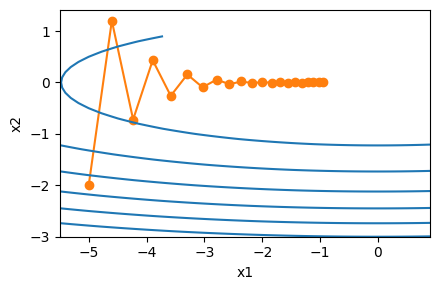

In [3]:
from utils.helper import show_trace_2d, train_2d

eta = 0.4
def f_2d(x1, x2):
    return 0.1 * x1 ** 2 + 2 * x2 ** 2
def gd_2d(x1, x2, s1, s2):
    return (x1 - eta * 0.2 * x1, x2 - eta * 4 * x2, 0, 0)

show_trace_2d(f_2d, train_2d(gd_2d))

By construction, the gradient in the $x_2$ direction is *much* higher and changes much more rapidly than in the horizontal $x_1$ direction. Thus we are stuck between two undesirable choices: if we pick a small learning rate we ensure that the solution does not diverge in the $x_2$ direction but we are saddled with slow convergence in the $x_1$ direction. Conversely, with a large learning rate we progress rapidly in the $x_1$ direction but diverge in $x_2$. The example below illustrates what happens even after a slight increase in learning rate from $0.4$ to $0.6$. Convergence in the $x_1$ direction improves but the overall solution quality is much worse.


epoch 20, x1: -0.387814, x2: -1673.365109


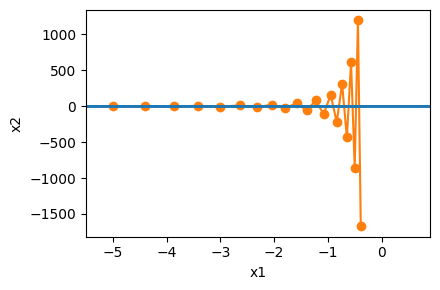

In [4]:
eta = 0.6
show_trace_2d(f_2d, train_2d(gd_2d))

### The Momentum Method

The momentum method allows us to solve the gradient descent problem described
above. Looking at the optimization trace above we might intuit that averaging gradients over the past would work well. After all, in the $x_1$ direction this will aggregate well-aligned gradients, thus increasing the distance we cover with every step. Conversely, in the $x_2$ direction where gradients oscillate, an aggregate gradient will reduce step size due to oscillations that cancel each other out.
Using $\mathbf{v}_t$ instead of the gradient $\mathbf{g}_t$ yields the following update equations:

$$
\begin{aligned}
\mathbf{v}_t &\leftarrow \beta \mathbf{v}_{t-1} + \mathbf{g}_{t, t-1}, \\
\mathbf{x}_t &\leftarrow \mathbf{x}_{t-1} - \eta_t \mathbf{v}_t.
\end{aligned}
$$

Note that for $\beta = 0$ we recover regular gradient descent. Before delving deeper into the mathematical properties let's have a quick look at how the algorithm behaves in practice.


epoch 20, x1: 0.007188, x2: 0.002553


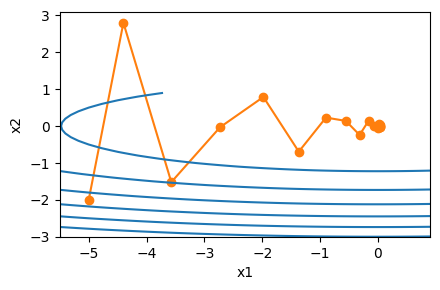

In [5]:
def momentum_2d(x1, x2, v1, v2):
    v1 = beta * v1 + 0.2 * x1
    v2 = beta * v2 + 4 * x2
    return x1 - eta * v1, x2 - eta * v2, v1, v2

eta, beta = 0.6, 0.5
show_trace_2d(f_2d, train_2d(momentum_2d))

As we can see, even with the same learning rate that we used before, momentum still converges well. Let's see what happens when we decrease the momentum parameter. Halving it to $\beta = 0.25$ leads to a trajectory that barely converges at all. Nonetheless, it is a lot better than without momentum (when the solution diverges).


epoch 20, x1: -0.126340, x2: -0.186632


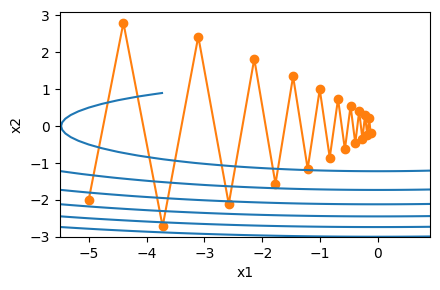

In [6]:
eta, beta = 0.6, 0.25
show_trace_2d(f_2d, train_2d(momentum_2d))

Note that we can combine momentum with stochastic gradient descent and in particular, minibatch stochastic gradient descent. The only change is that in that case we replace the gradients $\mathbf{g}_{t, t-1}$ with $\mathbf{g}_t$. Last, for convenience we initialize $\mathbf{v}_0 = 0$ at time $t=0$. Let's look at what leaky averaging actually does to the updates.

### Effective Sample Weight

Recall that $\mathbf{v}_t = \sum_{\tau = 0}^{t-1} \beta^{\tau} \mathbf{g}_{t-\tau, t-\tau-1}$. In the limit the terms add up to $\sum_{\tau=0}^\infty \beta^\tau = \frac{1}{1-\beta}$. In other words, rather than taking a step of size $\eta$ in gradient descent or stochastic gradient descent we take a step of size $\frac{\eta}{1-\beta}$ while at the same time, dealing with a potentially much better behaved descent direction. These are two benefits in one. To illustrate how weighting behaves for different choices of $\beta$ consider the diagram below.


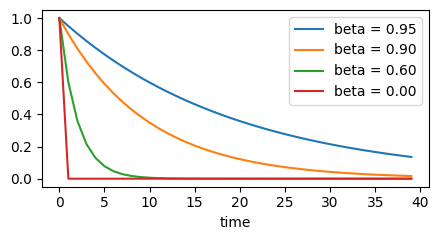

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def set_figsize(figsize=(4.5, 2.5)):
    plt.figure(figsize=figsize)

set_figsize()

betas = [0.95, 0.9, 0.6, 0]
for beta in betas:
    x = torch.arange(40).cpu().numpy()
    plt.plot(x, beta ** x, label=f'beta = {beta:.2f}')

plt.xlabel('time')
plt.legend()
plt.tight_layout()
plt.show()

## Practical Experiments

Let's see how momentum works in practice, i.e., when used within the context of a proper optimizer. For this we need a somewhat more scalable implementation.

### Implementation from Scratch

Compared with (minibatch) stochastic gradient descent the momentum method needs to maintain a set of  auxiliary variables, i.e., velocity. It has the same shape as the gradients (and variables of the optimization problem). In the implementation below we call these variables `states`.


In [8]:
def init_momentum_states(feature_dim):
    v_w = torch.zeros((feature_dim, 1))
    v_b = torch.zeros(1)
    return (v_w, v_b)

In [9]:
def sgd_momentum(params, states, hyperparams):
    for p, v in zip(params, states):
        with torch.no_grad():
            v[:] = hyperparams['momentum'] * v + p.grad
            p[:] -= hyperparams['lr'] * v
        p.grad.data.zero_()

Let's see how this works in practice.


In [10]:
from utils.helper import train_ch11, get_data_ch11

def train_momentum(lr, momentum, num_epochs=2):
    train_ch11(sgd_momentum, init_momentum_states(feature_dim),
                   {'lr': lr, 'momentum': momentum}, data_iter,
                   feature_dim, num_epochs)

data_iter, feature_dim = get_data_ch11(batch_size=10)
train_momentum(0.02, 0.5)

loss: 0.245, 0.031 sec/epoch


When we increase the momentum hyperparameter `momentum` to 0.9, it amounts to a significantly larger effective sample size of $\frac{1}{1 - 0.9} = 10$. We reduce the learning rate slightly to $0.01$ to keep matters under control.


In [11]:
train_momentum(0.01, 0.9)

loss: 0.252, 0.018 sec/epoch


Reducing the learning rate further addresses any issue of non-smooth optimization problems. Setting it to $0.005$ yields good convergence properties.


In [12]:
train_momentum(0.005, 0.9)

loss: 0.248, 0.017 sec/epoch


### Concise Implementation

There is very little to do in Gluon since the standard `sgd` solver already had momentum built in. Setting matching parameters yields a very similar trajectory.


In [14]:
from utils.helper import train_concise_ch11

trainer = torch.optim.SGD
train_concise_ch11(trainer, {'lr': 0.005, 'momentum': 0.9}, data_iter)

/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


loss: 6.837, 0.020 sec/epoch


## Theoretical Analysis

So far the 2D example of $f(x) = 0.1 x_1^2 + 2 x_2^2$ seemed rather contrived. We will now see that this is actually quite representative of the types of problem one might encounter, at least in the case of minimizing convex quadratic objective functions.

### Quadratic Convex Functions

Consider the function

$$h(\mathbf{x}) = \frac{1}{2} \mathbf{x}^\top \mathbf{Q} \mathbf{x} + \mathbf{x}^\top \mathbf{c} + b.$$

This is a general quadratic function. For positive definite matrices $\mathbf{Q} \succ 0$, i.e., for matrices with positive eigenvalues this has a minimizer at $\mathbf{x}^* = -\mathbf{Q}^{-1} \mathbf{c}$ with minimum value $b - \frac{1}{2} \mathbf{c}^\top \mathbf{Q}^{-1} \mathbf{c}$. Hence we can rewrite $h$ as

$$h(\mathbf{x}) = \frac{1}{2} (\mathbf{x} - \mathbf{Q}^{-1} \mathbf{c})^\top \mathbf{Q} (\mathbf{x} - \mathbf{Q}^{-1} \mathbf{c}) + b - \frac{1}{2} \mathbf{c}^\top \mathbf{Q}^{-1} \mathbf{c}.$$

The gradient is given by $\partial_{\mathbf{x}} h(\mathbf{x}) = \mathbf{Q} (\mathbf{x} - \mathbf{Q}^{-1} \mathbf{c})$. That is, it is given by the distance between $\mathbf{x}$ and the minimizer, multiplied by $\mathbf{Q}$. Consequently also the velocity  is a linear combination of terms $\mathbf{Q} (\mathbf{x}_t - \mathbf{Q}^{-1} \mathbf{c})$.

Since $\mathbf{Q}$ is positive definite it can be decomposed into its eigensystem via $\mathbf{Q} = \mathbf{O}^\top \boldsymbol{\Lambda} \mathbf{O}$ for an orthogonal (rotation) matrix $\mathbf{O}$ and a diagonal matrix $\boldsymbol{\Lambda}$ of positive eigenvalues. This allows us to perform a change of variables from $\mathbf{x}$ to $\mathbf{z} \stackrel{\textrm{def}}{=} \mathbf{O} (\mathbf{x} - \mathbf{Q}^{-1} \mathbf{c})$ to obtain a much simplified expression:

$$h(\mathbf{z}) = \frac{1}{2} \mathbf{z}^\top \boldsymbol{\Lambda} \mathbf{z} + b'.$$

Here $b' = b - \frac{1}{2} \mathbf{c}^\top \mathbf{Q}^{-1} \mathbf{c}$. Since $\mathbf{O}$ is only an orthogonal matrix this does not perturb the gradients in a meaningful way. Expressed in terms of $\mathbf{z}$ gradient descent becomes

$$\mathbf{z}_t = \mathbf{z}_{t-1} - \boldsymbol{\Lambda} \mathbf{z}_{t-1} = (\mathbf{I} - \boldsymbol{\Lambda}) \mathbf{z}_{t-1}.$$

The important fact in this expression is that gradient descent *does not mix* between different eigenspaces. That is, when expressed in terms of the eigensystem of $\mathbf{Q}$ the optimization problem proceeds in a coordinate-wise manner. This also holds for

$$\begin{aligned}
\mathbf{v}_t & = \beta \mathbf{v}_{t-1} + \boldsymbol{\Lambda} \mathbf{z}_{t-1} \\
\mathbf{z}_t & = \mathbf{z}_{t-1} - \eta \left(\beta \mathbf{v}_{t-1} + \boldsymbol{\Lambda} \mathbf{z}_{t-1}\right) \\
    & = (\mathbf{I} - \eta \boldsymbol{\Lambda}) \mathbf{z}_{t-1} - \eta \beta \mathbf{v}_{t-1}.
\end{aligned}$$

In doing this we just proved the following theorem: gradient descent with and without momentum for a convex quadratic function decomposes into coordinate-wise optimization in the direction of the eigenvectors of the quadratic matrix.

### Scalar Functions

Given the above result let's see what happens when we minimize the function $f(x) = \frac{\lambda}{2} x^2$. For gradient descent we have

$$x_{t+1} = x_t - \eta \lambda x_t = (1 - \eta \lambda) x_t.$$

Whenever $|1 - \eta \lambda| < 1$ this optimization converges at an exponential rate since after $t$ steps we have $x_t = (1 - \eta \lambda)^t x_0$. This shows how the rate of convergence improves initially as we increase the learning rate $\eta$ until $\eta \lambda = 1$. Beyond that things diverge and for $\eta \lambda > 2$ the optimization problem diverges.


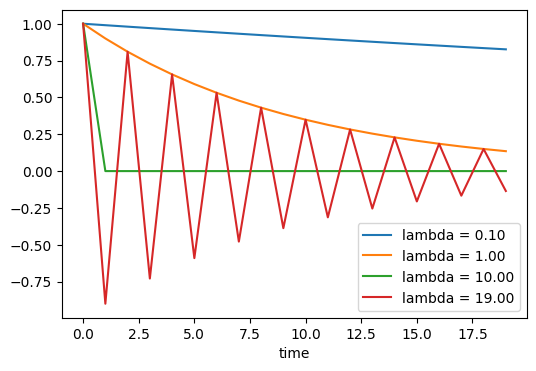

In [16]:
lambdas = [0.1, 1, 10, 19]
eta = 0.1
set_figsize((6, 4))
for lam in lambdas:
    t = torch.arange(20).detach().numpy()
    plt.plot(t, (1 - eta * lam) ** t, label=f'lambda = {lam:.2f}')
plt.xlabel('time')
plt.legend();

To analyze convergence in the case of momentum we begin by rewriting the update equations in terms of two scalars: one for $x$ and one for velocity $v$. This yields:

$$
\begin{bmatrix} v_{t+1} \\ x_{t+1} \end{bmatrix} =
\begin{bmatrix} \beta & \lambda \\ -\eta \beta & (1 - \eta \lambda) \end{bmatrix}
\begin{bmatrix} v_{t} \\ x_{t} \end{bmatrix} = \mathbf{R}(\beta, \eta, \lambda) \begin{bmatrix} v_{t} \\ x_{t} \end{bmatrix}.
$$

We used $\mathbf{R}$ to denote the $2 \times 2$ governing convergence behavior. After $t$ steps the initial choice $[v_0, x_0]$ becomes $\mathbf{R}(\beta, \eta, \lambda)^t [v_0, x_0]$. Hence, it is up to the eigenvalues of $\mathbf{R}$ to determine the speed of convergence. See the [Distill post](https://distill.pub/2017/momentum/) of :citet:`Goh.2017` for a great animation and :citet:`Flammarion.Bach.2015` for a detailed analysis. One can show that $0 < \eta \lambda < 2 + 2 \beta$ velocity converges. This is a larger range of feasible parameters when compared to $0 < \eta \lambda < 2$ for gradient descent. It also suggests that in general large values of $\beta$ are desirable. Further details require a fair amount of technical detail and we suggest that the interested reader consult the original publications.

## Summary

* Momentum replaces gradients with a leaky average over past gradients. This accelerates convergence significantly.
* It is desirable for both noise-free gradient descent and (noisy) stochastic gradient descent.
* Momentum prevents stalling of the optimization process that is much more likely to occur for stochastic gradient descent.
* The effective number of gradients is given by $\frac{1}{1-\beta}$ due to exponentiated downweighting of past data.
* In the case of convex quadratic problems this can be analyzed explicitly in detail.
* Implementation is quite straightforward but it requires us to store an additional state vector (velocity $\mathbf{v}$).
